In [1]:
from utils import ASSETS_DIR
import torch
import torch.nn.functional as F
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch.nn as nn
from utils.models import load_all_skops
import torch.optim as optim
from sklearn.utils import resample
from utils.dataset import undersample_dataset
import models.quantum.quantum_machine_learning as qml
from qiskit.circuit.library import real_amplitudes

La root del progetto è: C:\Users\feder\Desktop\Magistrale\Biometria\Progetto_Quantum\ProgettoQuantumBiometria\src


In [2]:
cfg = qml.ExperimentConfig(
    n_qubits=6,
    input_dim=32,
    readout_name="ZXY",
    ansatz_function=real_amplitudes
)

params = {
           'reps': cfg.reps,
             'ansatz_fun': cfg.ansatz_function,
               'entanglement': 'reverse_linear'
               }

torch.manual_seed(cfg.seed)
print(cfg.seed)

11


In [3]:

dimension_padded, num_blocks, pad_size = qml.zero_padding(cfg.n_qubits, cfg.input_dim)

final_data = qml.build_quantum_circuit(real_qubits=cfg.n_qubits,
                                        encoding_depth=num_blocks,
                                          **params)
quantum_circuit = final_data['quantum_circuit']
weight_params = final_data['weight_params']
input_params = final_data['input_params']
quantum_circuit.draw('mpl')
print(final_data['weight_params'])

Costruzione del layer 0 con 6 qubits reali e 36 qubits totali
Costruzione del layer 1 con 6 qubits reali e 36 qubits totali
Costruzione del layer 2 con 6 qubits reali e 36 qubits totali
Costruzione del layer 3 con 6 qubits reali e 36 qubits totali
Costruzione del layer 4 con 6 qubits reali e 36 qubits totali
Costruzione del layer 5 con 6 qubits reali e 36 qubits totali
[ParameterVectorElement(θ_0[0]), ParameterVectorElement(θ_0[1]), ParameterVectorElement(θ_0[2]), ParameterVectorElement(θ_0[3]), ParameterVectorElement(θ_0[4]), ParameterVectorElement(θ_0[5]), ParameterVectorElement(θ_0[6]), ParameterVectorElement(θ_0[7]), ParameterVectorElement(θ_0[8]), ParameterVectorElement(θ_0[9]), ParameterVectorElement(θ_0[10]), ParameterVectorElement(θ_0[11]), ParameterVectorElement(θ_0[12]), ParameterVectorElement(θ_0[13]), ParameterVectorElement(θ_0[14]), ParameterVectorElement(θ_0[15]), ParameterVectorElement(θ_0[16]), ParameterVectorElement(θ_0[17]), ParameterVectorElement(θ_1[0]), ParameterVe

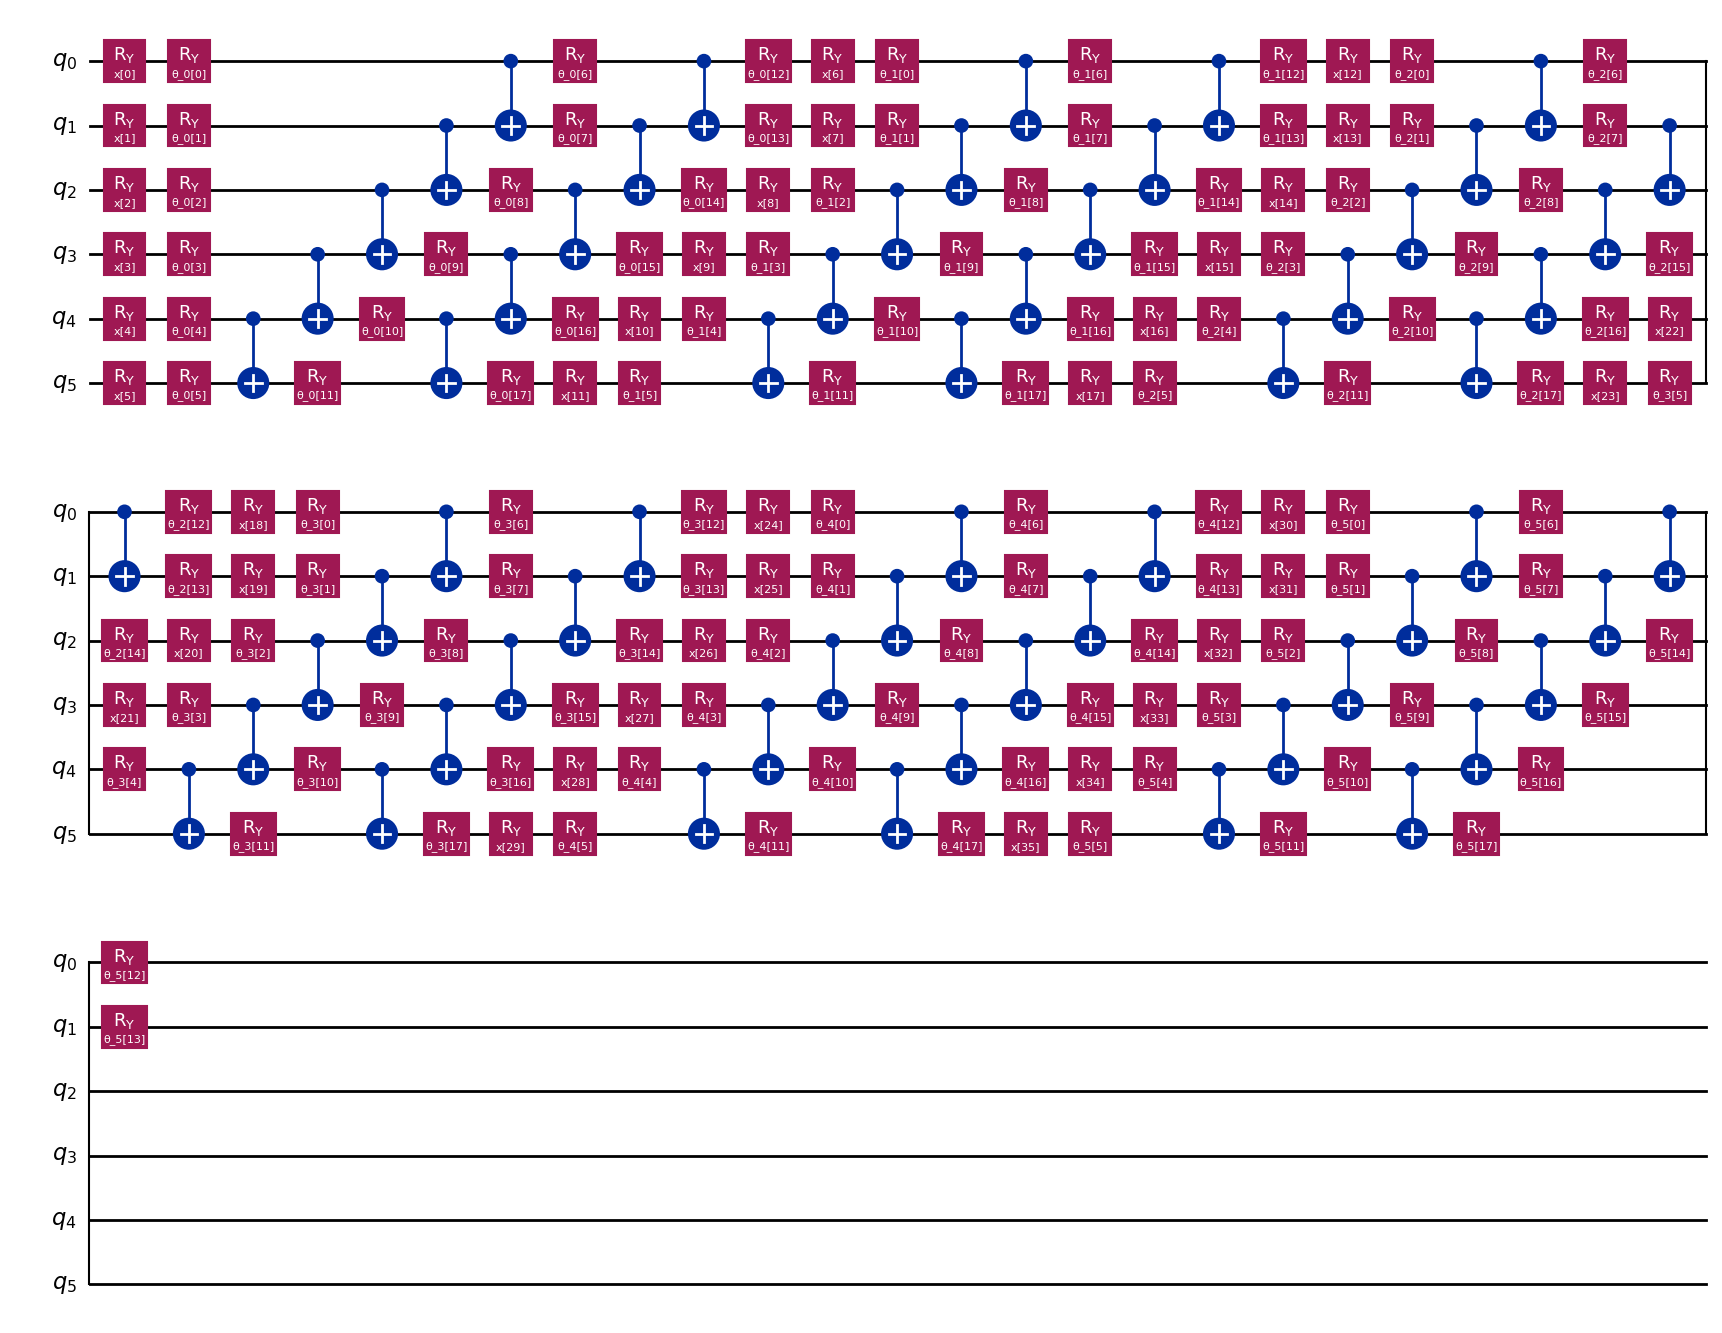

In [4]:
quantum_circuit.draw('mpl')

In [5]:

objs = load_all_skops(ASSETS_DIR / f"seeds_{cfg.seed}") 
objs.pop("scaler")
pca32 = objs[f"pca_{cfg.input_dim}"]

'''TRAIN DATAFRAME'''
train_dataset = pd.read_csv(ASSETS_DIR / f"seeds_{cfg.seed}/train_{cfg.seed}.csv")
train_dataset = undersample_dataset(train_dataset, label_col='label', random_seed=11)
train_dataset = resample(train_dataset, replace=False, n_samples=4000, stratify=train_dataset["label"], random_state=cfg.seed)
X_train = train_dataset.drop(columns=["label"])



'''VALIDATION DATAFRAME'''
val_dataset = pd.read_csv(ASSETS_DIR / f"seeds_{cfg.seed}/val_{cfg.seed}.csv")
val_dataset = undersample_dataset(val_dataset, label_col='label', random_seed=cfg.seed)


#PCA su train
X_train = pca32.transform(X_train.values)
Y_train = train_dataset["label"]

#PCA su val
X_val = val_dataset.drop(columns=["label"])
X_val = pca32.transform(X_val.values)
Y_val = val_dataset["label"]

'''TEST DATAFRAME'''
test_dataset = pd.read_csv(ASSETS_DIR / f"seeds_{cfg.seed}/test_{cfg.seed}.csv")
X_test = test_dataset.drop(columns=["label"])
X_test = pca32.transform(X_test.values)
Y_test = test_dataset["label"]



Caricamento di: pca_16.skops...
pca_16 caricato con successo.
Caricamento di: pca_32.skops...
pca_32 caricato con successo.
Caricamento di: pca_4.skops...
pca_4 caricato con successo.
Caricamento di: pca_8.skops...
pca_8 caricato con successo.
Caricamento di: scaler.skops...
scaler caricato con successo.
Dimensione classe minoritaria trovata: 7093 elementi.
Dimensione classe minoritaria trovata: 886 elementi.


In [6]:
del train_dataset
del val_dataset
del test_dataset

scaler = MinMaxScaler(feature_range=(0, np.pi/2))
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

tensor = torch.from_numpy(X_train).float()
tensor.size()
tensor_Y = torch.from_numpy(Y_train.values).long()

tensor_val = torch.from_numpy(X_val).float()
tensor_Y_val = torch.from_numpy(Y_val.values).long()

tensor_test = torch.from_numpy(X_test).float()
tensor_Y_test = torch.from_numpy(Y_test.values).long()

C:\Users\feder\AppData\Local\Temp\ipykernel_27112\4263343187.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  tensor_Y = torch.from_numpy(Y_train.values).long()


In [7]:
'''from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
import time

# Stratified 5-fold cross-validation (separate cell, non-invasive)
X_np = X_padded.numpy()
y_np = Y_train.values

X_val_np = X_padded_val.numpy()
y_val_np = Y_val.values

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1 = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_np, y_np), start=1):
    print(f"\nFold {fold}")
    train_ds = torch.utils.data.TensorDataset(torch.from_numpy(X_np[train_idx]).float(), torch.from_numpy(y_np[train_idx]).long())
    val_ds = torch.utils.data.TensorDataset(torch.from_numpy(X_np[val_idx]).float(), torch.from_numpy(y_np[val_idx]).long())
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=6, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=6, pin_memory=True)

    # Recreate a fresh model for this fold
    
    model = qml.VQC(num_qubits, quantum_circuit=final_circuit, obs=observables, weight_params=weight_params, input_params=input_params, target_classes=4, gradient_mode='estimator_pauli_batched_spsa')
    model.to('cuda')
    optimizer_fold = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    # Train with early stopping per fold
    best_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to('cuda', non_blocking=True)
            batch_y = batch_y.to('cuda', non_blocking=True)
            optimizer_fold.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer_fold.step()
            running_loss += loss.item()
        # Validation
        model.eval()
        val_loss = 0.0
        y_true = []
        y_pred = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to('cuda', non_blocking=True)
                batch_y = batch_y.to('cuda', non_blocking=True)
                logits = model(batch_X)
                loss = criterion(logits, batch_y)
                val_loss += loss.item()
                preds = logits.argmax(dim=1).cpu().numpy()
                y_pred.extend(preds.tolist())
                y_true.extend(batch_y.cpu().numpy().tolist())
        val_loss = val_loss / len(val_loader)
        print(f"Fold {fold} Epoch {epoch+1}/{epochs} - Train loss: {running_loss/len(train_loader):.4f} Val loss: {val_loss:.4f}")
        # Early stopping
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping')
                break
    # Load best weights
    model.load_state_dict({k: v.to('cuda') for k, v in best_state.items()})

    # Final evaluation on validation fold
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to('cuda', non_blocking=True)
            batch_y = batch_y.to('cuda', non_blocking=True)
            logits = model(batch_X)
            preds = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(batch_y.cpu().numpy().tolist())
    f1 = f1_score(y_true, y_pred, average='macro')
    print(classification_report(y_true, y_pred))
    print(f"Fold {fold} F1 (macro): {f1:.4f}")
    fold_f1.append(f1)

print(f"\nCross-validated F1 (macro) per fold: {fold_f1}")
print(f"Mean F1 (macro): {np.mean(fold_f1):.4f}")'''

'from sklearn.model_selection import StratifiedKFold\nfrom sklearn.metrics import f1_score, classification_report\nimport time\n\n# Stratified 5-fold cross-validation (separate cell, non-invasive)\nX_np = X_padded.numpy()\ny_np = Y_train.values\n\nX_val_np = X_padded_val.numpy()\ny_val_np = Y_val.values\n\nkfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\nfold_f1 = []\n\nfor fold, (train_idx, val_idx) in enumerate(kfold.split(X_np, y_np), start=1):\n    print(f"\nFold {fold}")\n    train_ds = torch.utils.data.TensorDataset(torch.from_numpy(X_np[train_idx]).float(), torch.from_numpy(y_np[train_idx]).long())\n    val_ds = torch.utils.data.TensorDataset(torch.from_numpy(X_np[val_idx]).float(), torch.from_numpy(y_np[val_idx]).long())\n    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=6, pin_memory=True)\n    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=6, pin_memory=True)\n\n  

In [8]:


X_padded = F.pad(tensor, (0, pad_size), mode="constant", value=0.0)


dataset_train = torch.utils.data.TensorDataset(
    X_padded.float(),
    torch.from_numpy(Y_train.values).long()
)
print(f"Dataset train size: {dataset_train.__len__()} samples")
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=cfg.batch_size, shuffle=True, num_workers=12, pin_memory=True)

X_padded_val = F.pad(tensor_val, (0, pad_size), mode="constant", value=0.0)
dataset_val = torch.utils.data.TensorDataset(
    X_padded_val.float(),
    torch.from_numpy(Y_val.values).long()
)
print(f"Dataset val size: {dataset_val.__len__()} samples")
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=cfg.batch_size, shuffle=False, num_workers=12, pin_memory=True)



Dataset train size: 4000 samples
Dataset val size: 3544 samples


In [9]:

observables = qml.pauli_observable(cfg.n_qubits, cfg.readout_name)
print(observables)

quantum_model = qml.VQC(cfg.n_qubits, 
                        quantum_circuit=quantum_circuit,
                        obs=observables,
                        weight_params=weight_params,
                        input_params=input_params,
                        target_classes=cfg.num_classes,
                        gradient_mode='estimator_pauli_batched_spsa',)
quantum_model.to("cuda")

[SparsePauliOp(['IIIIIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIZII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIZIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIXII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIYII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIYIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIIII'],
              coeffs=[1.+0.j]), SparsePauliOp

VQC(
  (head_classical_linear_layer): Linear(in_features=18, out_features=4, bias=True)
)

In [10]:
epochs = 50
optimizer = optim.Adam(quantum_model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


In [16]:
# Specifica bando: 15 bin, uniformi, norma L1 [1] direttive progetto
from torchmetrics.classification import MulticlassCalibrationError
ece_metric = MulticlassCalibrationError(num_classes=4, n_bins=15, norm='l1').to("cuda")

# Aggiorna il dizionario report per includere le nuove metriche obbligatorie [2]
report = {
    "epoch": [], "train_loss": [], "val_loss": [], 
    "val_f1": [], "val_auroc": [], "val_bacc": [], "val_ece": [], 
    "epoch_time": []
}

In [17]:
import time
from sklearn.metrics import f1_score, balanced_accuracy_score,roc_auc_score, classification_report


for epoch in range(epochs):
    
    running_loss = 0.0
    start_time = time.time()
    one_time = True

    quantum_model.train()
    # Il dataloader_train fornisce iterativamente i batch (es. da 32)
    for batch_X, batch_y in dataloader_train:
        
        if one_time:
            print(f"Batch size: {batch_X[0].shape}")
            print(f"Use batched estimator SPSA: {quantum_model._use_batched_estimator_spsa}")
            one_time = False
        

        batch_X = batch_X.to("cuda", non_blocking=True)
        batch_y = batch_y.to("cuda", non_blocking=True)
        
        # A. Azzeriamo i gradienti
        optimizer.zero_grad()
        
        # B. FORWARD PASS
        # Qui la QNN crea in automatico il PUB per l'intero batch e lo esegue
        logits = quantum_model(batch_X)
       

        '''print(f"Shape di logits: {logits.shape}")
        print(f"Shape di batch_y: {batch_y.shape}")
        print(f"Tipo di batch_y: {batch_y.dtype}")'''
        
        # C. Calcolo della Loss
        loss = criterion(logits, batch_y)
        loss.backward()
        # E. Aggiornamento dei pesi
        optimizer.step()
        
        running_loss += loss.item()
        print("#", end="")
    print()  # Per andare a capo dopo la barra di avanzamento
        # --- VALIDAZIONE ---
    quantum_model.eval()
    ece_metric.reset() # Reset ad ogni epoca per ECE, per vedere calibrazione specifica sulla SINGOLA EPOCA
    with torch.no_grad():
        val_loss = 0.0
        y_true = []
        y_pred = []
        y_probs = []
        for batch_X, batch_y in dataloader_val:
            batch_X = batch_X.to("cuda", non_blocking=True)
            batch_y = batch_y.to("cuda", non_blocking=True)
            logits = quantum_model(batch_X)

            # Trasformazione logit -> probabilità per AUROC ed ECE [1]
            probs = torch.softmax(logits, dim=1)
            ece_metric.update(probs, batch_y)

            loss = criterion(logits, batch_y)
            val_loss += loss.item()

            preds = logits.argmax(dim=1).cpu().numpy()
            y_probs.extend(probs.cpu().numpy().tolist()) 
            # Si può sintetizzare con y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
            y_pred.extend(preds.tolist()) 
            y_true.extend(batch_y.cpu().numpy().tolist())

        val_loss = val_loss / len(dataloader_val)
        b_acc = balanced_accuracy_score(y_true, y_pred)
        auroc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        ece_val = ece_metric.compute().item()
        f1 = f1_score(y_true, y_pred, average='macro')
        print(f"Classification Report E{epoch+1}:\n{classification_report(y_true, y_pred)}")
        #print(f"Val loss: {val_loss:.4f}")
        #print(f"Val F1: {f1:.4f}")


    step_time = time.time() - start_time
        
    print(f"Tempo per epoca {epoch+1}: {step_time:.2f} secondi")
    loss_media = running_loss / len(dataloader_train)

    '''Versione estesa
    report["val_loss"].append(val_loss)
    report["val_f1"].append(f1)
    report["epoch_time"].append(step_time)
    report["train_loss"].append(loss_media)
    report["epoch"].append(epoch+1)'''
    # REPORT SINTETIZZATO (vedi blocco jupyter sopra per struttura, il successivo è blocco stampa)
    for key, val in zip(report.keys(), [epoch+1, loss_media, val_loss/len(dataloader_val), f1, auroc, b_acc, ece_val, step_time]):
        report[key].append(val)

    print(f"Epoca {epoch+1}/{epochs} - Loss: {loss_media:.4f} | F1: {f1:.4f} | AUROC: {auroc:.4f} | ECE: {ece_val:.4f}")

Batch size: torch.Size([36])
Use batched estimator SPSA: True
################################
Classification Report E1:
              precision    recall  f1-score   support

           0       0.68      0.65      0.66       886
           1       0.70      0.65      0.67       886
           2       0.55      0.58      0.57       886
           3       0.66      0.70      0.68       886

    accuracy                           0.64      3544
   macro avg       0.65      0.64      0.65      3544
weighted avg       0.65      0.64      0.65      3544

Tempo per epoca 1: 25.51 secondi
Epoca 1/50 - Loss: 0.8136 | F1: 0.6453 | AUROC: 0.8694 | ECE: 0.0339
Batch size: torch.Size([36])
Use batched estimator SPSA: True
################################
Classification Report E2:
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       886
           1       0.69      0.65      0.67       886
           2       0.56      0.55      0.56       886
    

In [18]:
#Test codice con tutte metriche
print("\n--- PERFORMANCE MEDIE SU TUTTE LE EPOCHE ---")
for metric_name in ["val_f1", "val_auroc", "val_bacc", "val_ece"]:
    avg_val = np.mean(report[metric_name])
    print(f"{metric_name.replace('val_', '').upper()} medio: {avg_val:.4f}")


--- PERFORMANCE MEDIE SU TUTTE LE EPOCHE ---
F1 medio: 0.6488
AUROC medio: 0.8717
BACC medio: 0.6500
ECE medio: 0.0266


In [20]:
for epoch, val_loss, val_f1 in zip(report["epoch"], report["val_loss"], report["val_f1"]):
    #print(f"Epoch {epoch}: Val Loss = {val_loss:.4f}, Val F1 = {val_f1:.4f}")
    pass
f1_avg = np.mean(report["val_f1"])
print(f"\nF1 medio su tutte le epoche: {f1_avg:.4}")


F1 medio su tutte le epoche: 0.6488
